In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from squarenet import SquareNet, samplepoints
from squarenet.utils import show_search_result

In [26]:
save_path = "sqrnet/plot" #for the plots

## ❒ SquareNet

Fitting our first dataset
-1 million points randomly sampled on the 2D map of France

In [27]:
I = 1_000
N = I*I
points = samplepoints("france", size = (N, 2))
sn = SquareNet(gridshape = (I, I))
sn.fit(points, method = "robust")

Starting gridification... available method [fast, robust]
selected robust

=== Carthesian sort ===
[█████████████████████████████] 100/100

=== Final Status ===
succesfully sorted at iteration 115


Now France is grided

figure will be saved at sqrnet\plot.png


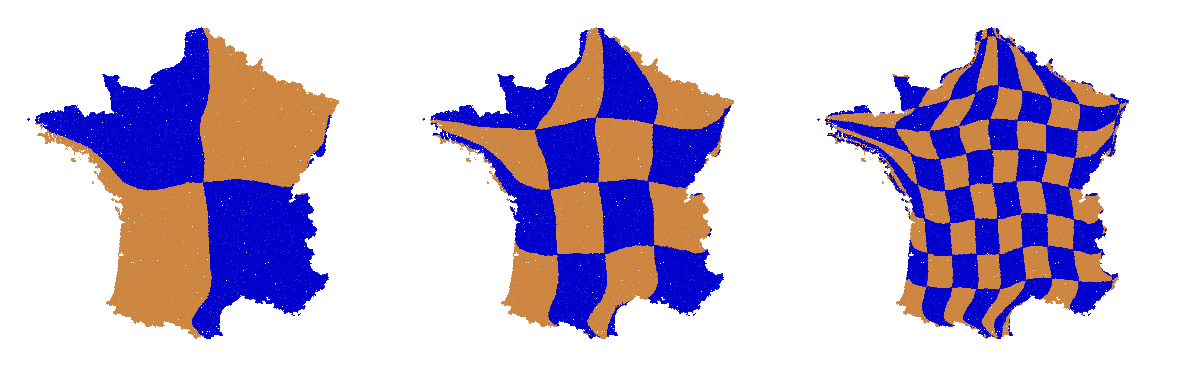

(<Figure size 1200x400 with 3 Axes>, None)

In [28]:
sn.plot(style = "checkerboard", save_path = save_path) #should look like a checkerboard pattern

Squarenet allow for a powerfull D-dimensional version of the 1D search sorted

true index (np.int32(133), np.int32(410))
with search sorted: [132 409] [134 411]


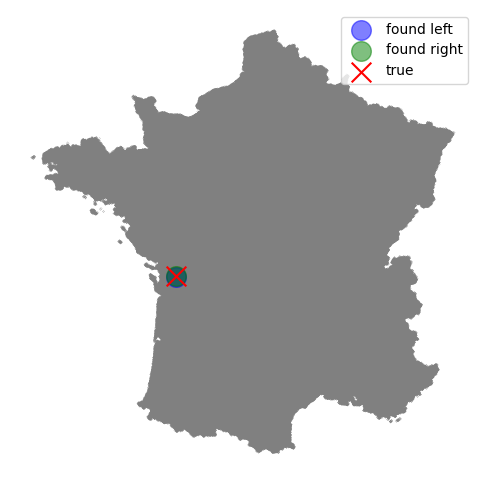

In [29]:
#(x, y) coordinates of a random point in France
true_index = np.random.choice(N)
grid_multi_index = sn.mapidx(true_index)
point = points[true_index] 

#search sorted is a heuristic method that will find an
# (almost optimal) position in the grid that best 
# fit the spatial coordinates of an unseen point.
# Augment n_iter to get better accuracy

left_multi_index = sn.search_sorted(point, n_iter = 4, side = "left") 
right_multi_index = sn.search_sorted(point, n_iter = 4, side = "right")


show_search_result(left_multi_index, right_multi_index, true_index, points, sn)

Fitting some holy dataset, again 1 million points in 2D

In [30]:
I = 1_000
N = I*I
points = samplepoints("holy", size = (N, 2))
sn = SquareNet(gridshape = (I, I))

sn.fit(points)

Starting gridification... available method [fast, robust]
selected fast

=== Carthesian sort ===
[█████████████████████████████] 100/100

=== Final Status ===
succesfully sorted at iteration 16


figure will be saved at sqrnet\plot_1.png


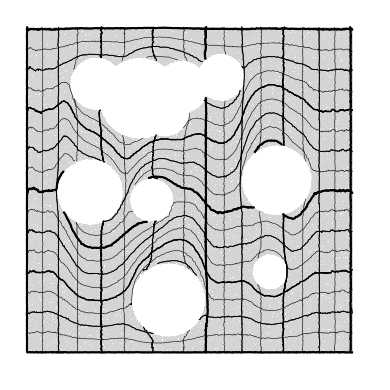

(<Figure size 400x400 with 1 Axes>, None)

In [31]:
sn.plot(style = "mesh", save_path = save_path)

Neighbormap estimate nearest neighbors count in relative position of the grid
 -> quick check for the grid quality

In [32]:
sn.neighbormap(log2 = True)

neighbor map on axes (0, 1) (log2 count)
                         0                          0   
    0        1     0  2  3  2  1  2                     
       0  2  2  3  3  4  6  6  6  5  4  2  2  1  0  0  0
          0  3  3  5  7  9  9  9  7  6  4  4  2  2     0
                1  4  8 10  ■ 10  8  4  0               
    0  0  2  3  4  6  7  9  9  9  7  5  4  3  0  1      
 0  1  1  1  2  1  4  5  6  6  6  4  3  3  1  2  1  0   
    0        0  1  1  2  2  1  2  2  1  0  0  0  0      
                                                 0     0


Fitting something spiky (1million points, 3D). Method = robust gives better result, especially for spiky geometries

In [33]:
I = 100
N = I*I*I
points = samplepoints("spiky", size = (N, 3))
sn = SquareNet(gridshape = (I, I, I))

sn.fit(points, method = "robust")

Starting gridification... available method [fast, robust]
selected robust

=== Carthesian sort ===
[█████████████████████████████] 100/100

=== Final Status ===
succesfully sorted at iteration 120


figure will be saved at sqrnet\plot.gif
ffmpeg unavailable. Npoints = 1000000 and style is 'scatter' -> could take 1/2 minutes


(<Figure size 400x400 with 1 Axes>,
 <matplotlib.animation.FuncAnimation at 0x1e7007a3050>)

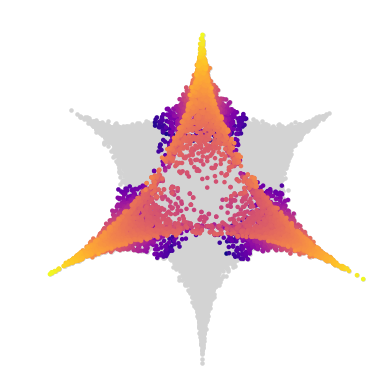

In [34]:
sn.plot(animate = True, style = "scatter", save_path = save_path)

Fitting a Manifold (1million points, 2d latent loop in a 4D space). Just put 1 for some of the grid dimensions

In [35]:
I = 1_000
N = I*I*1*1
points = samplepoints("4Dloop", size = (N, 4))
sn = SquareNet(gridshape = (I, I, 1, 1))

sn.fit(points)

Starting gridification... available method [fast, robust]
selected fast

=== Carthesian sort ===
[█████████████████████████████] 100/100

=== Final Status ===
succesfully sorted at iteration 30


figure will be saved at sqrnet\plot_1.gif
ffmpeg unavailable. Npoints = 1000000 and style is 'scatter' -> could take 1/2 minutes


(<Figure size 400x400 with 1 Axes>,
 <matplotlib.animation.FuncAnimation at 0x1e7007a3c50>)

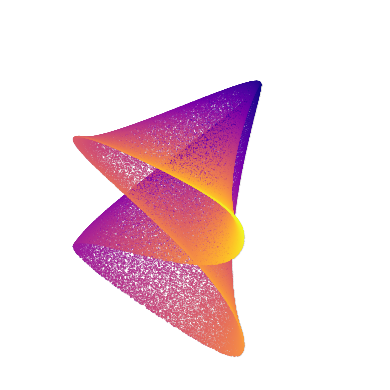

In [36]:
sn.plot(style = "scatter", animate = True, save_path = save_path)